# Mini Project:

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import root_mean_squared_error


In [42]:
pd.set_option('display.max_columns', None)
# this below code will ignore any warnings appear after running the cell.
import warnings
warnings.filterwarnings('ignore')

## Part 1: Data Exploration

In [43]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [44]:
train_data.shape

(1460, 81)

In [45]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [46]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The dataset contains 1460 rows and 81 columns. There are 38 columns of type **numeric**, while 43 columns of type **object**. The dataset conains **"Nan"** values. And some columns shows outliers. This indicates that machine learning model must be clean first before insering diretly into training.

## Part 2: Data Cleaning

### Missing Values

In [47]:
# This line of code prints all columns where there are missing values in train data set.
train_cols = train_data.columns
missing_train_cols = []
missing_train_val = []
for col in train_cols:
    if train_data[col].isnull().sum() > 0:
        missing_train_cols.append(col)
        missing_train_val.append(train_data[col].isnull().sum())
        print(f"column {col} have {train_data[col].isnull().sum()} missing values.")
# print(missing_train_cols,missing_train_val)

column LotFrontage have 259 missing values.
column Alley have 1369 missing values.
column MasVnrType have 872 missing values.
column MasVnrArea have 8 missing values.
column BsmtQual have 37 missing values.
column BsmtCond have 37 missing values.
column BsmtExposure have 38 missing values.
column BsmtFinType1 have 37 missing values.
column BsmtFinType2 have 38 missing values.
column Electrical have 1 missing values.
column FireplaceQu have 690 missing values.
column GarageType have 81 missing values.
column GarageYrBlt have 81 missing values.
column GarageFinish have 81 missing values.
column GarageQual have 81 missing values.
column GarageCond have 81 missing values.
column PoolQC have 1453 missing values.
column Fence have 1179 missing values.
column MiscFeature have 1406 missing values.


In [48]:
# Here I have filled numerical values with median
train_data['LotFrontage'].fillna(train_data['LotFrontage'].median(), inplace=True)
train_data['MasVnrArea'].fillna(train_data['MasVnrArea'].median(), inplace=True)
train_data['GarageYrBlt'].fillna(train_data['GarageYrBlt'].median(), inplace=True)

# Here I have filled categorical values with mode (there were few missing values)
train_data['Electrical'].fillna(train_data['Electrical'].mode()[0], inplace=True)

# Here I have filled categorical values with median
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in bsmt_cols:
    train_data[col].fillna('None', inplace=True)

# Filled Garage features having missing values with "None" that means "No Garage"
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in garage_cols:
    train_data[col].fillna('None', inplace=True)

# columns having high missing values replaced with None as well.
high_missing_cols = ['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
for col in high_missing_cols:
    train_data[col].fillna('None', inplace=True)

# Special case
train_data['MasVnrType'].fillna('None', inplace=True)

# Check if any missing values remain
print(train_data.isnull().sum().sort_values(ascending=False).head(10))

Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
Alley          0
LotShape       0
LandContour    0
Utilities      0
dtype: int64


In [49]:
# This line of code prints all columns where there are missing values in test data set
test_cols = test_data.columns
missing_test_cols = []
missing_test_val = []
for col in test_cols:
    if test_data[col].isnull().sum() > 0:
        missing_test_cols.append(col)
        missing_test_val.append(test_data[col].isnull().sum())
        print(f"column {col} have {test_data[col].isnull().sum()} missing values.")
# print(missing_train_cols,missing_train_val)

column MSZoning have 4 missing values.
column LotFrontage have 227 missing values.
column Alley have 1352 missing values.
column Utilities have 2 missing values.
column Exterior1st have 1 missing values.
column Exterior2nd have 1 missing values.
column MasVnrType have 894 missing values.
column MasVnrArea have 15 missing values.
column BsmtQual have 44 missing values.
column BsmtCond have 45 missing values.
column BsmtExposure have 44 missing values.
column BsmtFinType1 have 42 missing values.
column BsmtFinSF1 have 1 missing values.
column BsmtFinType2 have 42 missing values.
column BsmtFinSF2 have 1 missing values.
column BsmtUnfSF have 1 missing values.
column TotalBsmtSF have 1 missing values.
column BsmtFullBath have 2 missing values.
column BsmtHalfBath have 2 missing values.
column KitchenQual have 1 missing values.
column Functional have 2 missing values.
column FireplaceQu have 730 missing values.
column GarageType have 76 missing values.
column GarageYrBlt have 78 missing val

In [50]:
# Here I am filling numerical columns using median from training data
# (we use train data stats so model doesn't learn from test data)
num_cols = [
    'LotFrontage', 'MasVnrArea', 'GarageYrBlt',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath',
    'GarageCars', 'GarageArea'
]

for col in num_cols:
    test_data[col].fillna(train_data[col].median(), inplace=True)
# Here I am filling categorical columns with very few missing values using mode
# again taking mode from training data for consistency
cat_mode_cols = [
    'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
    'KitchenQual', 'Functional', 'SaleType'
]
for col in cat_mode_cols:
    test_data[col].fillna(train_data[col].mode()[0], inplace=True)
# Here missing basement-related values actually mean the house has no basement
# so instead of guessing, I simply mark them as "None"
bsmt_cols = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2'
]
for col in bsmt_cols:
    test_data[col].fillna('None', inplace=True)


# Same idea for garage features → missing means no garage exists
garage_cols = [
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]

for col in garage_cols:
    test_data[col].fillna('None', inplace=True)


# These columns have a lot of missing values and mostly represent optional features
# so I replaced missing values with "None" to indicate absence
high_missing_cols = [
    'Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'
]

for col in high_missing_cols:
    test_data[col].fillna('None', inplace=True)


# Special case: missing MasVnrType usually means no masonry veneer
test_data['MasVnrType'].fillna('None', inplace=True)


# Final check to make sure no major missing values are left
print(test_data.isnull().sum().sort_values(ascending=False).head(10))

Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
Alley          0
LotShape       0
LandContour    0
Utilities      0
dtype: int64


I used **median imputation** for numerical features because it is robust to outliers and provides a better measure of central tendency for skewed data.

I applied **mode imputation** to categorical variables with few missing values, as it replaces missing entries with the most frequent category, maintaining data consistency.

For certain features, I filled missing values with **"None"** because the absence of data actually indicates that the feature does not exist in the house (e.g., no basement, no garage, or no pool), rather than being missing at random.

### Encoding

In [51]:
numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_data.select_dtypes(include=['object', 'category']).columns

numerical_data = train_data[numerical_cols]
categorical_data = train_data[categorical_cols]

print("Numerical Columns:", list(numerical_cols))
print("Categorical Columns:", list(categorical_cols))

Numerical Columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categorical Columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fireplace

In [52]:
binary_cols = []
multi_cols = []

for col in categorical_cols:
    if train_data[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

binary_data = train_data[binary_cols]
multi_data = train_data[multi_cols]

print("Binary Categorical Columns:", binary_cols)
print("Multi-class Categorical Columns:", multi_cols)

Binary Categorical Columns: ['Street', 'Utilities', 'CentralAir']
Multi-class Categorical Columns: ['MSZoning', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [53]:
ohe = OneHotEncoder(drop='first', sparse_output=False)

binary_encoded = pd.DataFrame(
    ohe.fit_transform(binary_data),
    columns=ohe.get_feature_names_out(binary_cols),
    index=binary_data.index
)
binary_encoded.head()

,Street_Pave,Utilities_NoSeWa,CentralAir_Y
0,1.0,0.0,1.0
1,1.0,0.0,1.0
2,1.0,0.0,1.0
3,1.0,0.0,1.0
4,1.0,0.0,1.0


In [54]:
multi_encoded = multi_data.copy()
le_dict = {}
for col in multi_cols:
    le = LabelEncoder()
    multi_encoded[col] = le.fit_transform(multi_encoded[col])
    le_dict[col] = le
multi_encoded.head()

,MSZoning,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,3,1,3,3,4,0,5,2,2,0,5,1,1,12,13,1,2,4,2,2,4,3,2,6,1,0,4,2,6,3,1,2,5,5,2,3,4,1,8,4
1,3,1,3,3,2,0,24,1,2,0,2,1,1,8,8,2,3,4,1,2,4,1,0,6,1,0,4,3,6,5,1,2,5,5,2,3,4,1,8,4
2,3,1,0,3,4,0,5,2,2,0,5,1,1,12,13,1,2,4,2,2,4,2,2,6,1,0,4,2,6,5,1,2,5,5,2,3,4,1,8,4
3,3,1,0,3,0,0,6,2,2,0,5,1,1,13,15,2,3,4,0,4,1,3,0,6,1,2,4,2,6,2,5,3,5,5,2,3,4,1,8,0
4,3,1,0,3,2,0,15,2,2,0,5,1,1,12,13,1,2,4,2,2,4,0,2,6,1,0,4,2,6,5,1,2,5,5,2,3,4,1,8,4


First, I separate the data into numerical and categorical features. After that, I divide the categorical data into binary and multi-category variables. The columns that have binary features are processed using One-Hot Encoding, while the features with more than two unique values are encoded using Label Encoding.

In [55]:
train_data_1 = pd.concat([numerical_data, binary_encoded, multi_encoded], axis=1)
train_data_1.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Street_Pave,Utilities_NoSeWa,CentralAir_Y,MSZoning,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,1.0,0.0,1.0,3,1,3,3,4,0,5,2,2,0,5,1,1,12,13,1,2,4,2,2,4,3,2,6,1,0,4,2,6,3,1,2,5,5,2,3,4,1,8,4
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500,1.0,0.0,1.0,3,1,3,3,2,0,24,1,2,0,2,1,1,8,8,2,3,4,1,2,4,1,0,6,1,0,4,3,6,5,1,2,5,5,2,3,4,1,8,4
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500,1.0,0.0,1.0,3,1,0,3,4,0,5,2,2,0,5,1,1,12,13,1,2,4,2,2,4,2,2,6,1,0,4,2,6,5,1,2,5,5,2,3,4,1,8,4
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000,1.0,0.0,1.0,3,1,0,3,0,0,6,2,2,0,5,1,1,13,15,2,3,4,0,4,1,3,0,6,1,2,4,2,6,2,5,3,5,5,2,3,4,1,8,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000,1.0,0.0,1.0,3,1,0,3,2,0,15,2,2,0,5,1,1,12,13,1,2,4,2,2,4,0,2,6,1,0,4,2,6,5,1,2,5,5,2,3,4,1,8,4


### Outliers

In [56]:
num_cols = numerical_cols
num_data = train_data_1[num_cols]

In [57]:
def remove_outliers_iqr(df):
    df_clean = df.copy()

    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
        ]

    return df_clean

In [58]:
cleaned_num_data = remove_outliers_iqr(num_data)

print("Original shape:", num_data.shape)
print("Cleaned shape:", cleaned_num_data.shape)

Original shape: (1460, 38)
Cleaned shape: (557, 38)


In [59]:
def cap_outliers_iqr(df):
    df_capped = df.copy()

    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_capped[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df_capped

In [60]:
cleaned_num_data = cap_outliers_iqr(num_data)

print("Original shape:", num_data.shape)
print("After capping:", cleaned_num_data.shape)

Original shape: (1460, 38)
After capping: (1460, 38)


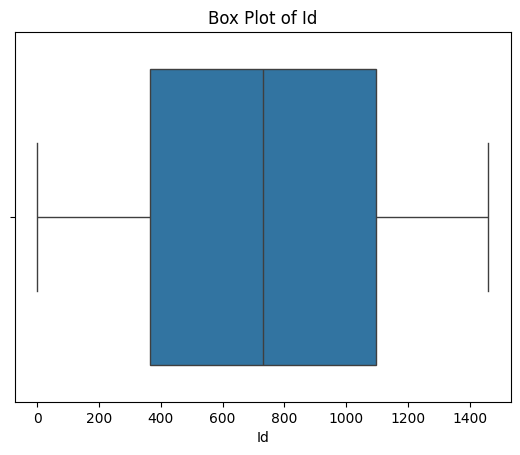

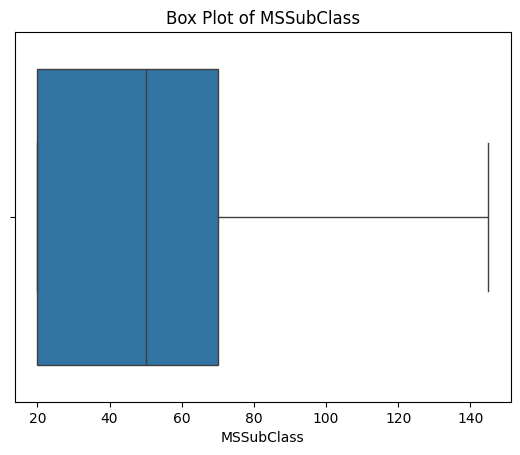

In [61]:
cols_to_plot = cleaned_num_data.columns[:2]
for col in cols_to_plot:
    plt.figure()
    sns.boxplot(x=cleaned_num_data[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

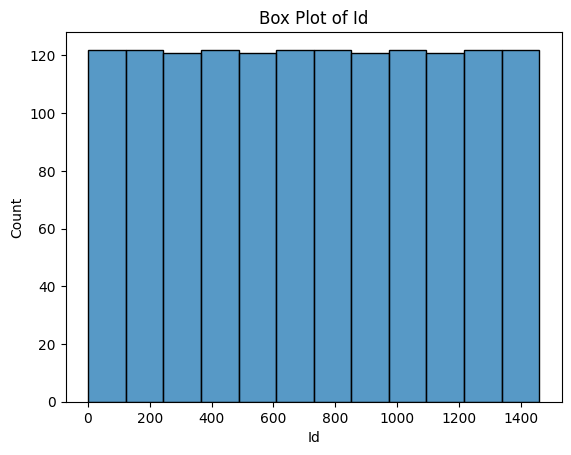

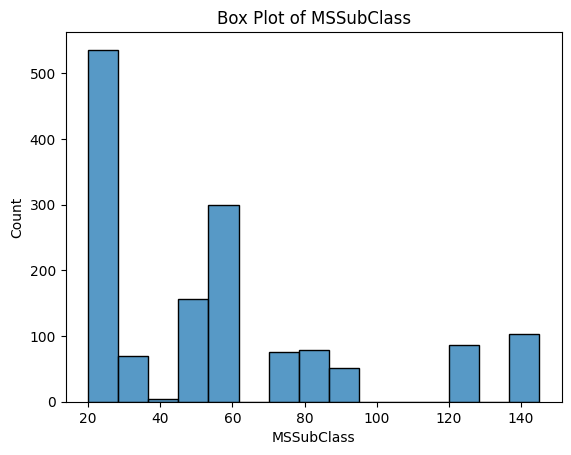

In [62]:
cols_to_plot = cleaned_num_data.columns[:2]
for col in cols_to_plot:
    plt.figure()
    sns.histplot(x=cleaned_num_data[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

First, I removed outliers directly. However, I found that after removing them, the number of rows decreased from 1460 to 557, which is a significant loss of data. Therefore, I chose a different approach and capped the outliers using the IQR method by replacing them with the upper and lower bounds

## Duplicate rows

In [63]:
train_data_1[train_data_1.duplicated(keep=False)]

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Street_Pave,Utilities_NoSeWa,CentralAir_Y,MSZoning,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition


In [64]:
train_data_1.duplicated().sum()

np.int64(0)

There is no duplicated row in the given dataset.

# Part 3: Model Building

## Linear Regression

In [65]:
train_data_1 = train_data_1.drop(columns="Id")
train_data_1.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Street_Pave,Utilities_NoSeWa,CentralAir_Y,MSZoning,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,1.0,0.0,1.0,3,1,3,3,4,0,5,2,2,0,5,1,1,12,13,1,2,4,2,2,4,3,2,6,1,0,4,2,6,3,1,2,5,5,2,3,4,1,8,4
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500,1.0,0.0,1.0,3,1,3,3,2,0,24,1,2,0,2,1,1,8,8,2,3,4,1,2,4,1,0,6,1,0,4,3,6,5,1,2,5,5,2,3,4,1,8,4
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500,1.0,0.0,1.0,3,1,0,3,4,0,5,2,2,0,5,1,1,12,13,1,2,4,2,2,4,2,2,6,1,0,4,2,6,5,1,2,5,5,2,3,4,1,8,4
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000,1.0,0.0,1.0,3,1,0,3,0,0,6,2,2,0,5,1,1,13,15,2,3,4,0,4,1,3,0,6,1,2,4,2,6,2,5,3,5,5,2,3,4,1,8,0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000,1.0,0.0,1.0,3,1,0,3,2,0,15,2,2,0,5,1,1,12,13,1,2,4,2,2,4,0,2,6,1,0,4,2,6,5,1,2,5,5,2,3,4,1,8,4


I need one feature to apply linear regression model,  
First I am finding the correlation of features with column "SalePrice". Then, the higher correlated value column will be chosen.

In [66]:
corr = train_data_1.corr(numeric_only=True)
sale_corr = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print(sale_corr)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
                  ...   
GarageType     -0.415283
GarageFinish   -0.425684
KitchenQual    -0.589189
BsmtQual       -0.593734
ExterQual      -0.636884
Name: SalePrice, Length: 79, dtype: float64


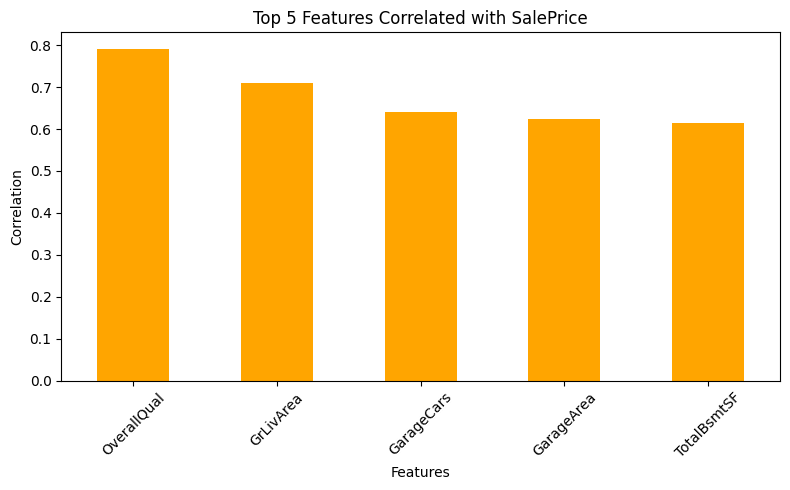

In [67]:
top5 = sale_corr.head(5)
plt.figure(figsize=(8,5))
top5.plot(kind='bar', color="orange")
plt.title('Top 5 Features Correlated with SalePrice')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

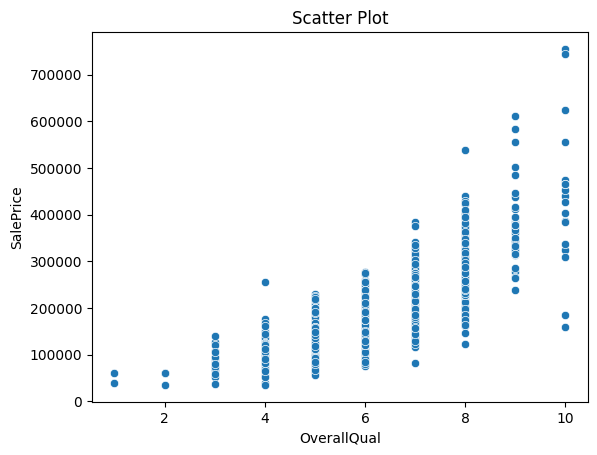

In [106]:
sns.scatterplot(x=train_data["OverallQual"], y=train_data["SalePrice"])
plt.title("Scatter Plot")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.show()

## Feature Scaling

In [68]:
X = train_data_1[["OverallQual"]]
y = train_data_1["SalePrice"]

In [69]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [70]:
scaler = StandardScaler()

In [71]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [72]:
lr = LinearRegression()

In [73]:
lr.fit(x_train_scaled, y_train)

LinearRegression()

The features have been scaled. Now, we can use these scaled feature to predict **"SalePrice"** column.

It is clear that **"OverallQual"** has higher correlation value with SalePrice columns. That's why, I am choosing this feaure for my linear regression model.

In [74]:
y_pred = lr.predict(x_test_scaled)

In [77]:
dic = pd.DataFrame({"Actual_SalePrice": y_test, "Predicted_Predict": y_pred})
dic.head()

,Actual_SalePrice,Predicted_Predict
892,154500,175619.797107
1105,325000,264446.352170
413,115000,131206.519575
522,159000,175619.797107
1036,315500,308859.629702


In [93]:
m = lr.coef_[0]
b = lr.intercept_

In [94]:
equation = f"y = {m:.2f}x + {b:.2f}"
equation

'y = 60878.17x + 181312.69'

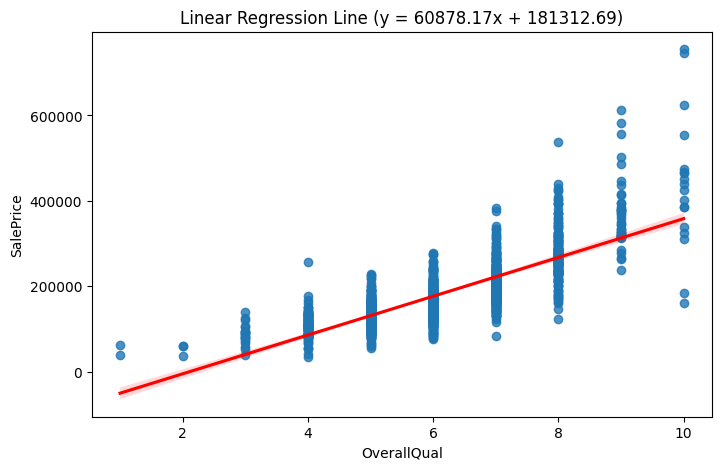

In [103]:
plt.figure(figsize=(8,5))
sns.regplot(x=train_data["OverallQual"], y=train_data["SalePrice"], line_kws={"color": "red"})

plt.title(f"Linear Regression Line ({equation})")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")

plt.show()

### R^2

In [99]:
print("R^2")
r_squared = lr.score(x_test_scaled, y_test)
print(f"{r_squared:.2f}")

R^2
0.64


##RMSE

In [100]:
print("Root Mean Squared Error")
print(f"{root_mean_squared_error(y_test, y_pred) :.2f}")

Root Mean Squared Error
49834.02


## Prediction

In [80]:
test_data_1 = test_data[["OverallQual"]]
test_data_1.head()

,OverallQual
0,5
1,6
2,5
3,6
4,8


In [81]:
scaled_data = scaler.transform(test_data_1)

In [82]:
prediction = lr.predict(scaled_data)

In [117]:
prediction_df = pd.DataFrame({
    "ID": test_data["Id"],
    "SalePrice": prediction
})

prediction_df.head()

,ID,SalePrice
0,1461,131206.519575
1,1462,175619.797107
2,1463,131206.519575
3,1464,175619.797107
4,1465,264446.352170


In [118]:
prediction_df.to_csv("prediction.csv", index=False)

#Conclusion

The Linear Regression model was trained using only the feature OverallQual to predict house prices (SalePrice). The model achieved an R² score of 0.64, which indicates that around 64% of the variation in house prices can be explained by the overall quality of the house. This shows that OverallQual is a strong and important predictor of house prices.

However, the Root Mean Squared Error (RMSE) of approximately 49,834 indicates that the model’s predictions deviate from the actual prices by nearly $50,000 on average. This level of error suggests that while the model captures the general trend, it is not highly precise for individual predictions.

Overall, the results show that a single feature model provides a reasonable baseline performance, but house prices depend on multiple factors. Therefore, including more relevant features would likely improve accuracy and reduce prediction error significantly.